In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [86]:
folder = Path("data/images")

image_paths = []

for ext in ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff"]:
    image_paths.extend(folder.glob(ext))

image_paths = sorted(image_paths)

images = {}

for path in image_paths:
    img = cv.imread(str(path), cv.IMREAD_GRAYSCALE)
    if img is not None:
        images[path.stem] = img

In [ ]:
# For the final processing, the optimized OpenCV functions cv.medianBlur() and cv.GaussianBlur() were used.
# def median_filter(image, kernel_size=5):
#     pad = kernel_size // 2
#     padded = np.pad(image, pad, mode="reflect")
#     result = np.zeros_like(image)
#     height, width = image.shape

#     for i in range(height):
#         for j in range(width):
#             window = padded[
#                 i:i + kernel_size,
#                 j:j + kernel_size
#             ]
#             result[i, j] = np.median(window)
#     return result

# def gaussian_kernel(size, sigma=1):
#     size = int(size) // 2
#     x, y = np.mgrid[-size:size+1, -size:size+1]
#     g =  np.exp(-((x**2 + y**2) / (2.0*sigma**2))) / (2.0 * np.pi * sigma**2)
#     g = g / g.sum()
#     return g

# def gaussian_filter(image, size=5, sigma=1.4):
#     kernel = gaussian_kernel(size, sigma)
#     return cv.filter2D(src=image, ddepth=-1, kernel=kernel)

In [ ]:
filtered_images = {}

for name, image in images.items():

    filtered_images[name] = {
        # "Median": median_filter(image, 3),
        # "Gaussian": gaussian_filter(image, 5, 1)
        "Median": cv.medianBlur(image, 5),
        "Gaussian": cv.GaussianBlur(image, (5, 5), sigmaX=1.4)
        }

In [107]:
def calculate_gradient(image, kernel_x, kernel_y, return_direction=False):
    gx = cv.filter2D(src=image, ddepth=cv.CV_64F, kernel=kernel_x)
    gy = cv.filter2D(src=image, ddepth=cv.CV_64F, kernel=kernel_y)

    magnitude = np.sqrt(gx**2 + gy**2)

    if magnitude.max() > 0:
        magnitude = magnitude / magnitude.max() * 255

    if return_direction:
        theta = np.arctan2(gy, gx)
        return magnitude, theta

    return magnitude.astype(np.uint8)

In [108]:
def sobel_operator(image, return_direction=False):
    kernel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float64)

    kernel_y = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float64)

    return calculate_gradient(image, kernel_x, kernel_y, return_direction)

In [109]:
def scharr_operator(image):

    kernel_x = np.array([
        [-3, 0, 3],
        [-10, 0, 10],
        [-3, 0, 3]
    ], dtype=np.float64)

    kernel_y = np.array([
        [ -3, -10, -3],
        [  0,   0,  0],
        [  3,  10,  3]
    ], dtype=np.float64)

    return calculate_gradient(image, kernel_x, kernel_y)

In [110]:
def prewitt_operator(image):

    kernel_x = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float64)

    kernel_y = np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]
    ], dtype=np.float64)

    return calculate_gradient(image, kernel_x, kernel_y)

In [111]:
def non_max_suppression(img, D):
    M, N = img.shape
    Z = np.zeros((M,N), dtype=np.int32)
    angle = D * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1,M-1):
        for j in range(1,N-1):
            try:
                q = 255
                r = 255

                #angle 0
                if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                    q = img[i, j+1]
                    r = img[i, j-1]
                #angle 45
                elif (22.5 <= angle[i,j] < 67.5):
                    q = img[i+1, j-1]
                    r = img[i-1, j+1]
                #angle 90
                elif (67.5 <= angle[i,j] < 112.5):
                    q = img[i+1, j]
                    r = img[i-1, j]
                #angle 135
                else: #elif (112.5 <= angle[i,j] < 157.5):
                    q = img[i-1, j-1]
                    r = img[i+1, j+1]

                if (img[i,j] >= q) and (img[i,j] >= r):
                    Z[i,j] = img[i,j]
                else:
                    Z[i,j] = 0

            except IndexError as e:
                pass

    return Z

In [112]:
def threshold(img, lowThresholdRatio=0.09, highThresholdRatio=0.17, weak=125, strong=255):

    highThreshold = img.max() * highThresholdRatio;
    lowThreshold = highThreshold * lowThresholdRatio;

    M, N = img.shape
    res = np.zeros((M,N), dtype=np.int32)

    strong_i, strong_j = np.where(img >= highThreshold)
    zeros_i, zeros_j = np.where(img < lowThreshold)

    weak_i, weak_j = np.where((img <= highThreshold) & (img >= lowThreshold))

    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak

    return res


In [113]:
def strong_or_weak_edges(img, value=255):
    M, N = img.shape
    res = np.zeros((M,N), dtype=np.int32)

    strong_i, strong_j = np.where(img == value)
    res[strong_i, strong_j] = value

    return res

In [114]:
def cannyEdgeDetector(img, lowthreshold=0.09, highthreshold=0.17):
    gradientMat, thetaMat = sobel_operator(img, return_direction=True)
    nonMaxImg = non_max_suppression(gradientMat, thetaMat)
    thresholdImg = threshold(nonMaxImg, lowthreshold, highthreshold)

    img_final = strong_or_weak_edges(thresholdImg)

    return img_final

In [115]:
operators = {
    "Sobel": sobel_operator,
    "Scharr": scharr_operator,
    "Prewitt": prewitt_operator,
    "Canny": cannyEdgeDetector
}

edge_results = {}

for name, filtered in filtered_images.items():
    edge_results[name] = {}

    for filter_name, image in filtered.items():
        for operator_name, operator in operators.items():
            result = operator(image)
            edge_results[name][f"{filter_name}_{operator_name}"] = result

In [116]:
results_folder = Path("results")
results_folder.mkdir(exist_ok=True)

for name, results in edge_results.items():
    image_folder = results_folder / name
    image_folder.mkdir(exist_ok=True)

    for result_name, result in results.items():
        save_path = image_folder / f"{result_name}.png"
        cv.imwrite(str(save_path), result.astype(np.uint8))

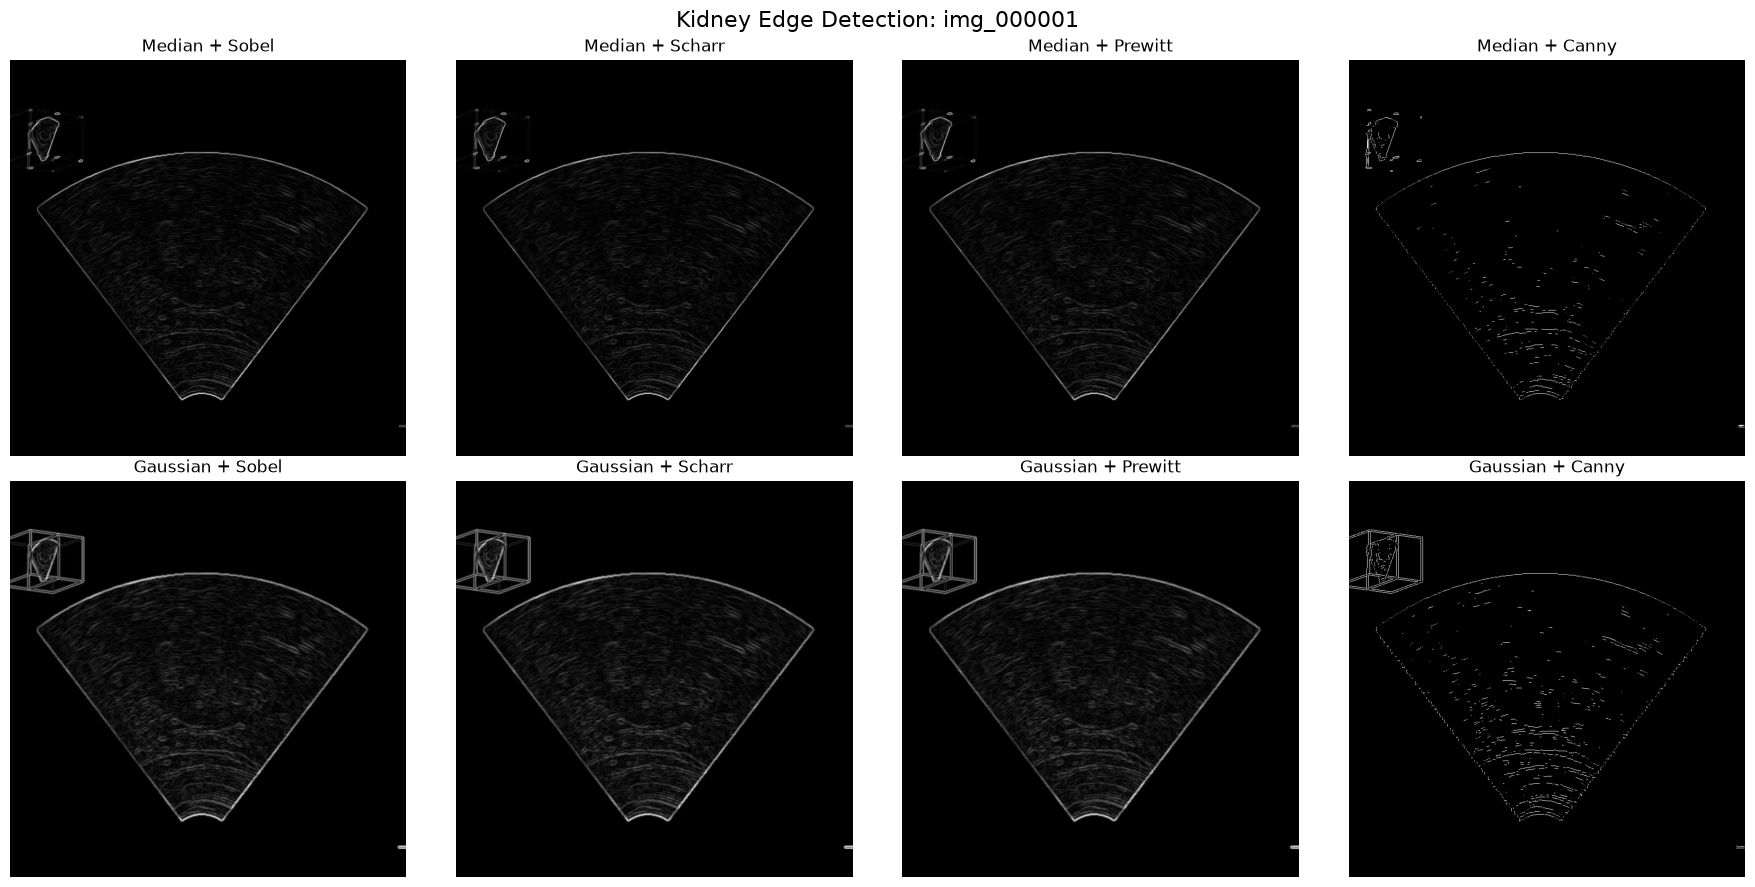

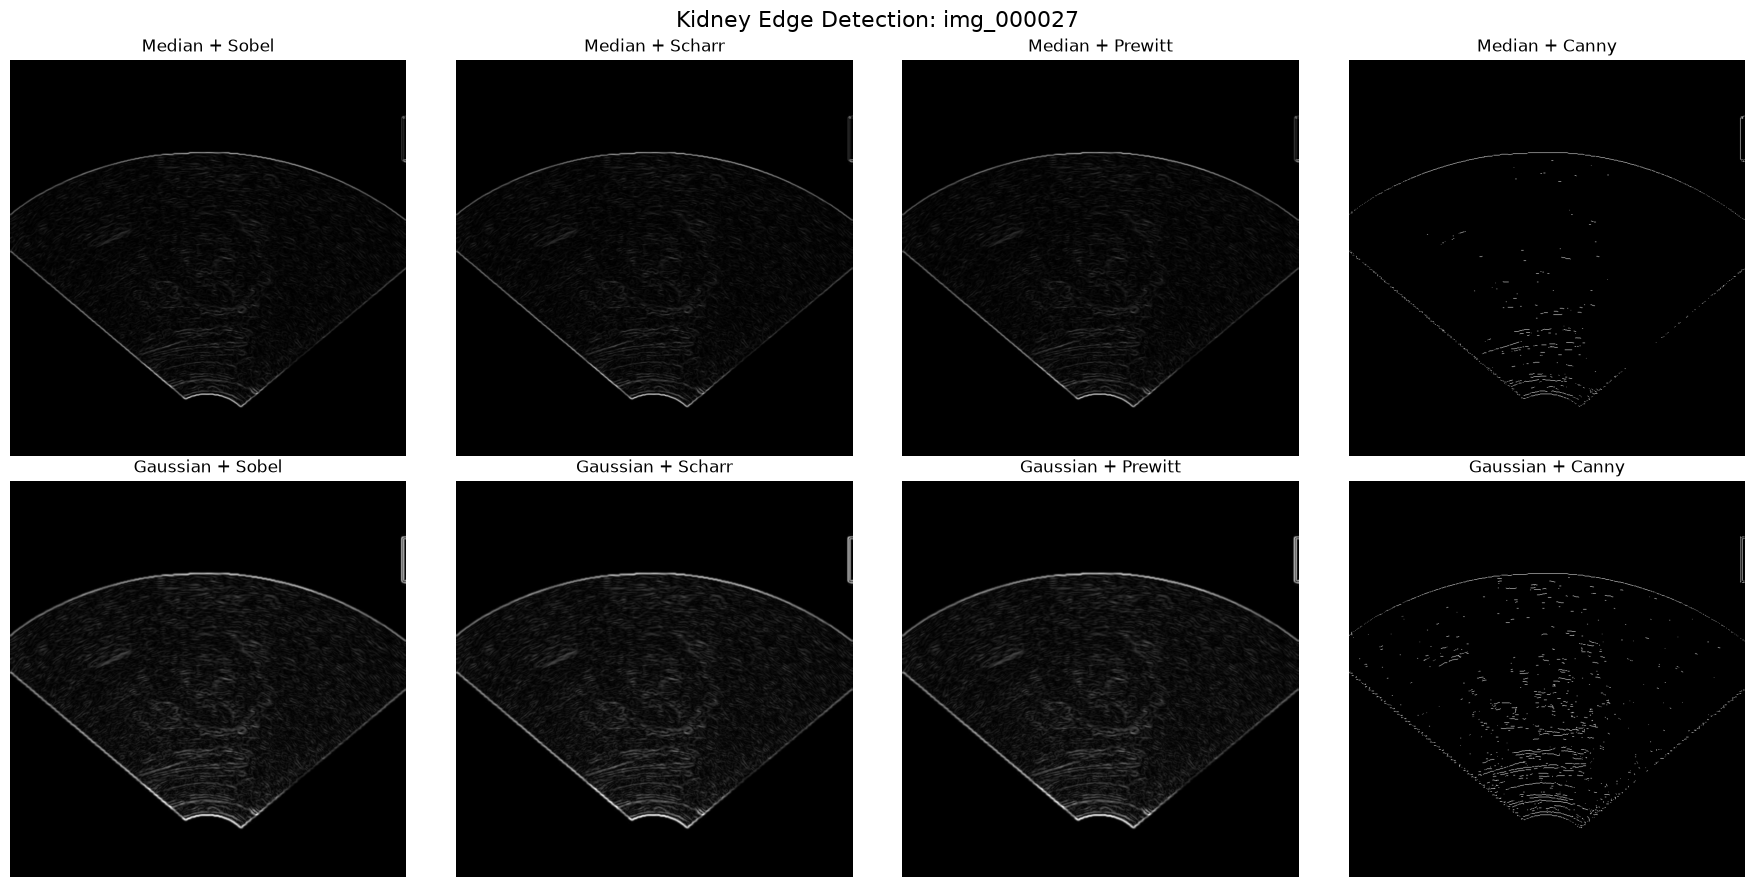

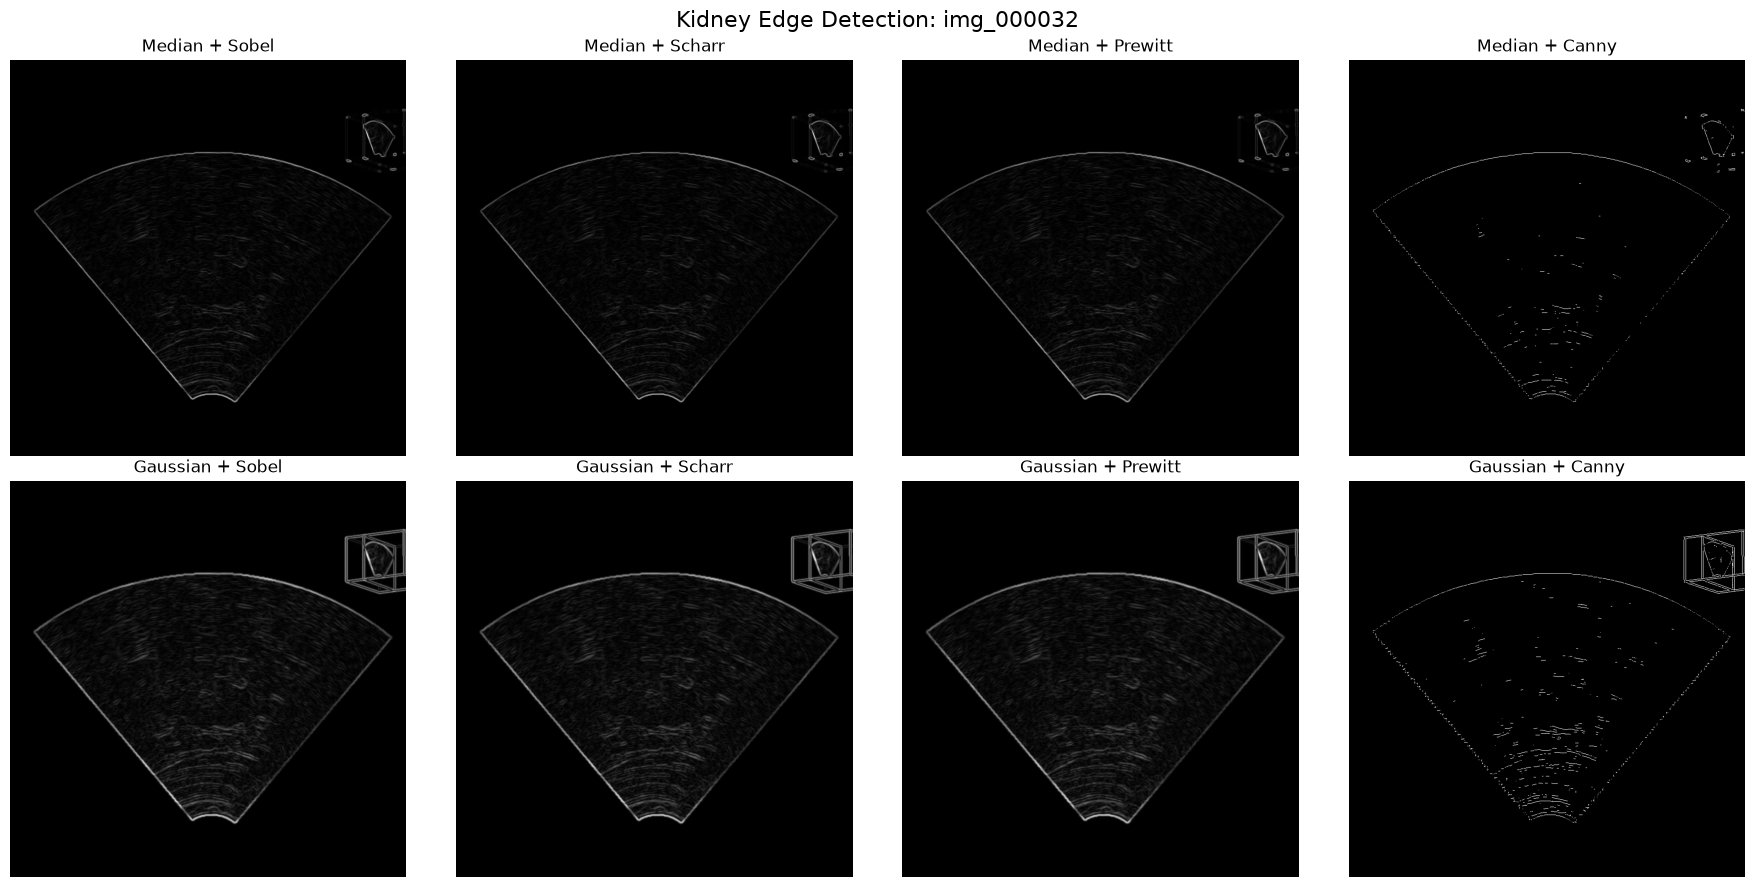

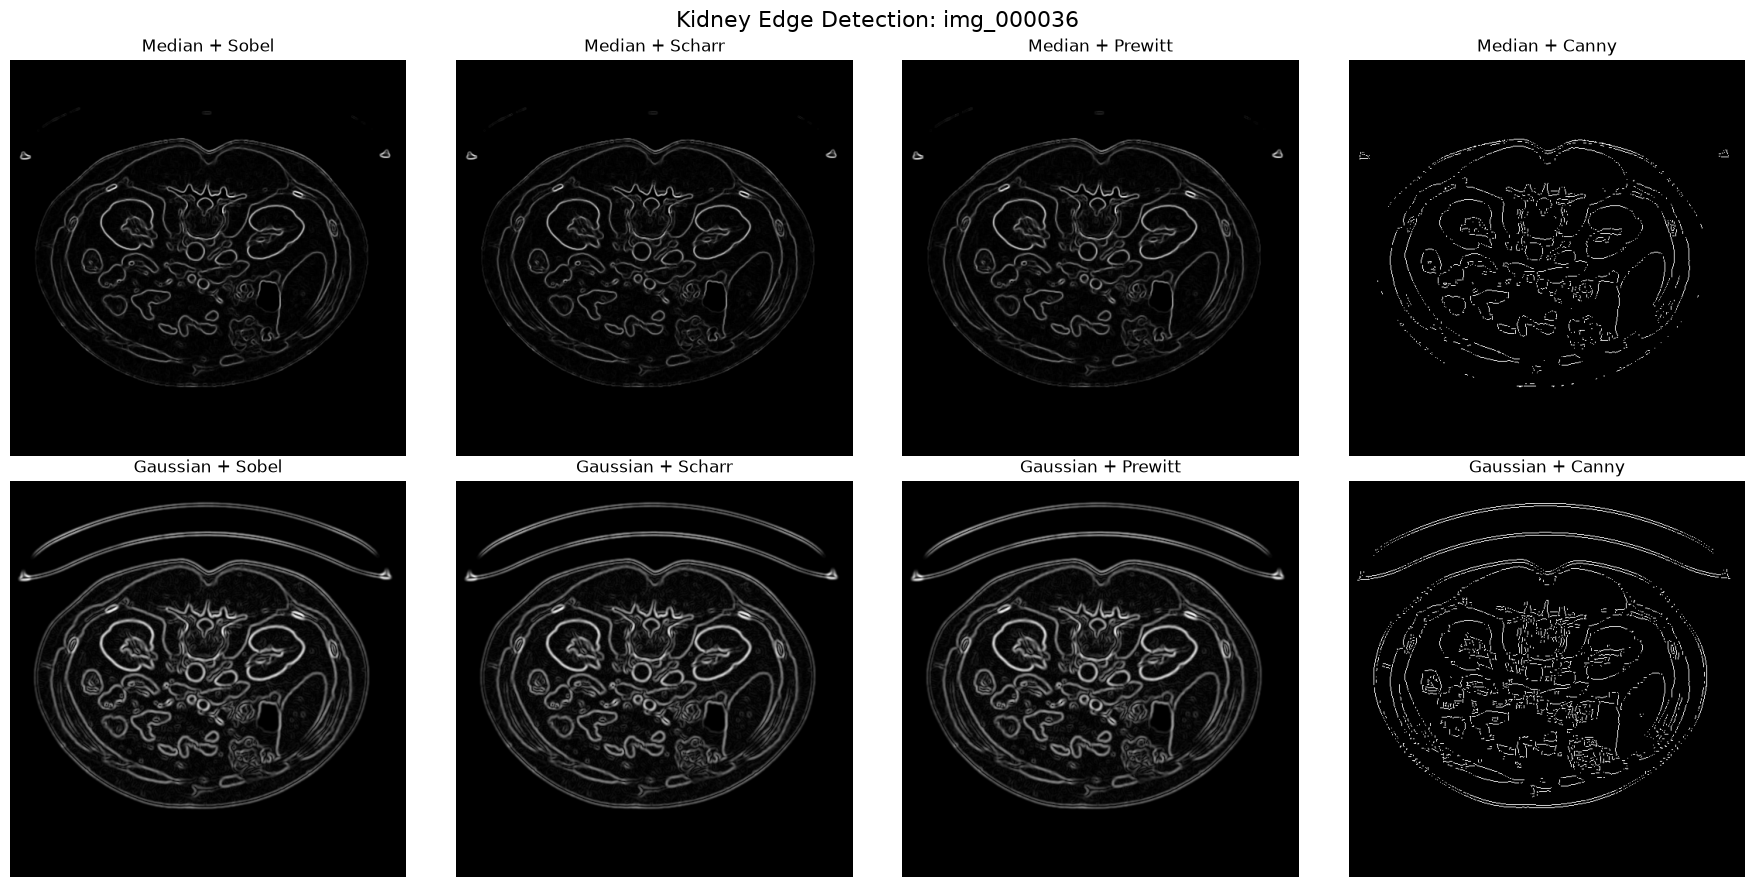

In [ ]:
filter_names = ["Median", "Gaussian"]
operator_names = ["Sobel", "Scharr", "Prewitt", "Canny"]

for name, results in edge_results.items():
    fig, axs = plt.subplots(2, 4, figsize=(18, 9))

    for i, filter_name in enumerate(filter_names):
        for j, operator_name in enumerate(operator_names):
            key = f"{filter_name}_{operator_name}"
            img = results[key]

            axs[i, j].imshow(img, cmap="gray", vmin=0, vmax=255)
            axs[i, j].set_title(f"{filter_name} + {operator_name}")
            axs[i, j].axis("off")

    fig.suptitle(f"Kidney Edge Detection: {name}", fontsize=16)

    plt.tight_layout()
    plt.show()

## Conclusion

Overall, none of the tested combinations produced a perfectly clear kidney contour, especially on the ultrasound images.

Sobel, Scharr, and Prewitt produced very similar results. Among these methods, the combination of the **Gaussian filter (5×5, σ = 1.4) and the Scharr operator** showed slightly clearer kidney boundaries in the visual comparison.

Canny produced thinner but more fragmented edges and often highlighted unrelated structures.

Therefore, **Gaussian + Scharr** was selected as the best of the tested combinations, although the overall quality of kidney edge detection remained limited.